In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# XGB with True + Pseudo Labels (Full dataset)

In [2]:
df = pd.read_csv('TRUE_PSEUDO_featData.csv')

In [3]:
# Define features and target
descr = ['CoordinationNumber','PseudoLabelled','NumElementsSurface',
         'meanAtomicRadius','maxAtomicRadius','minAtomicRadius','stdAtomicRadius',	
         'meanAtomicMass','maxAtomicMass','minAtomicMass','stdAtomicMass',
         'meanAffinity','maxAffinity','minAffinity','stdAffinity',
         'meanDensity','maxDensity','minDensity','stdDensity',
         'meanGroup','maxGroup','minGroup','stdGroup',
         'meanMeltingP','maxMeltingP','minMeltingP','stdMeltingP',
         'meanIon','maxIon','minIon','stdIon',
         'meanElectronegativity','maxElectronegativity','minElectronegativity','stdElectronegativity',
         'meanPcount','maxPcount','minPcount','stdPcount',
         'meanDcount','maxDcount','minDcount','stdDcount',
]

target = 'ReactionEnergy'

# Prepare data
X = df[descr]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

'''# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)'''

xgb_model = XGBRegressor(objective='reg:squarederror',colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 400, subsample= 0.8, random_state=42)

from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Define 5-fold cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(xgb_model, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")

====== Cross-Validated Results ======
Mean Train R²:  0.9148 ± 0.0067
Mean Test  R²:  0.8153 ± 0.0146
Mean Test  MAE: 0.2128 ± 0.0107
Mean Test  RMSE:0.3072 ± 0.0166


In [4]:
# !pip install shap
import shap

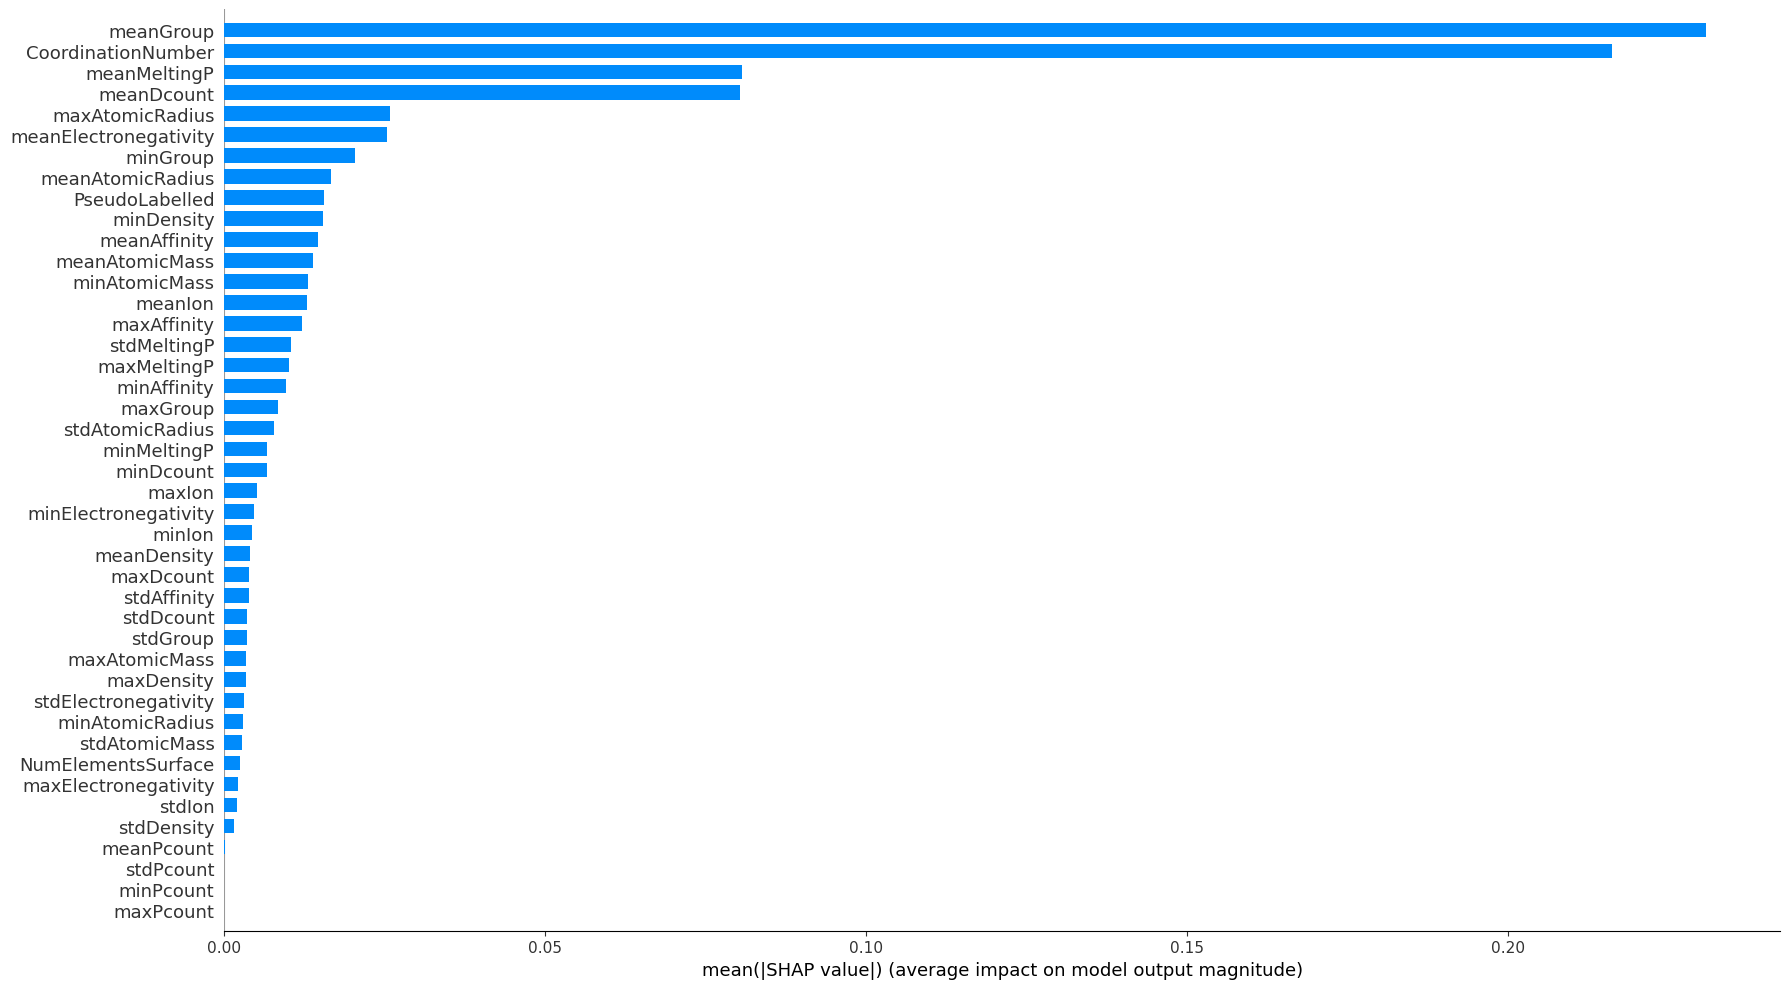

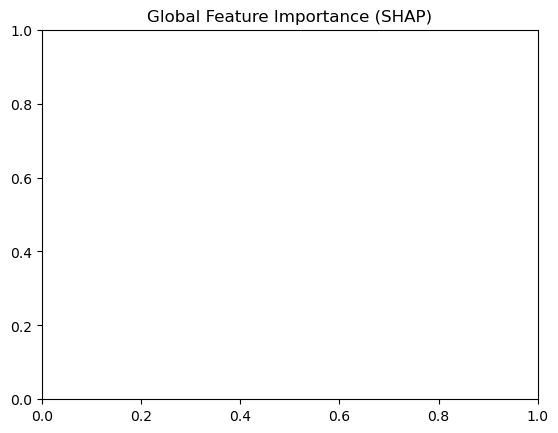

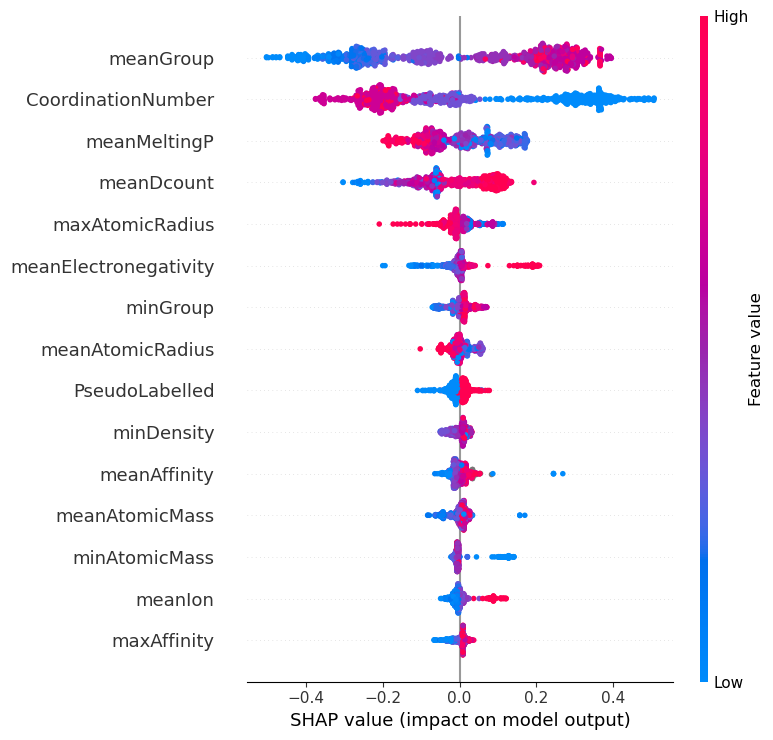

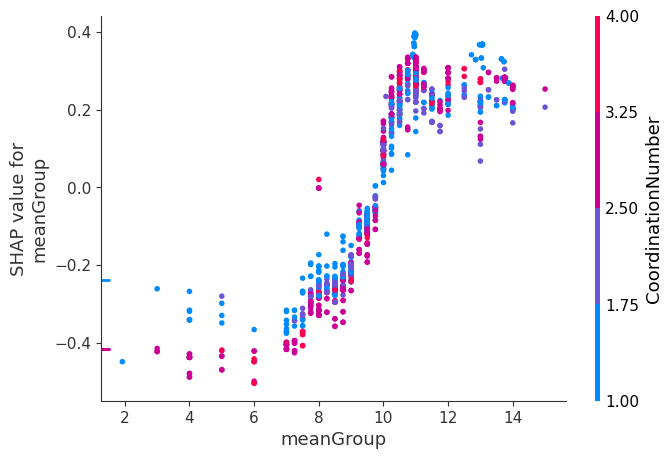

ValueError: operands could not be broadcast together with shapes (282,) (1124,) 

In [27]:
# Create a TreeExplainer for your XGB
xgb_model.fit(X_train, y_train)
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for all samples
shap_values = explainer.shap_values(X_train)  # For regression, returns a 2D array (samples x features)

# -------------------------------
# 1. Global Feature Importance
# -------------------------------
# This shows the mean absolute SHAP value per feature
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=43, plot_size=(18,10))
plt.title("Global Feature Importance (SHAP)")
plt.show()

# -------------------------------
# 2. Summary Dot Plot
# -------------------------------
# Shows feature impact across all samples
shap.summary_plot(shap_values, X_train, plot_type="dot", max_display=15)

# -------------------------------
# 3. Dependence Plot for a single feature
# -------------------------------
# Example: plot SHAP value vs feature value for 'PseudoLabelled'
if 'meanGroup' in X.columns:
    shap.dependence_plot('meanGroup', shap_values, X_train)

# -------------------------------
# 4. Optional: Identify top contributing features for outliers
# -------------------------------
# Compute residuals
y_pred = xgb_model.predict(X_train)
residuals = y_test - y_pred

# Pick the top 10 largest absolute residuals
outlier_pos = residuals.abs().sort_values(ascending=False).head(10).index
outlier_pos = [residuals.index.get_loc(i) for i in outlier_pos] 




# XGB with True + Pseudo Labels (Top 10 features only)

In [5]:
descr = ['meanGroup','CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minGroup', 'maxAtomicRadius','meanAtomicRadius',     
            'minDensity', 'meanElectronegativity']

target = "ReactionEnergy"

# Prepare data
X = df[descr]
y = df[target]

# Train-test split
X_train_top10, X_test_top10, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


'''# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0] }

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)'''

xgb_model_top10 = XGBRegressor(objective='reg:squarederror',colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 400, subsample= 0.8, random_state=42)

xgb_model_top10.fit(X_train_top10, y_train)

from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Define 5-fold cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(xgb_model_top10, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")


====== Cross-Validated Results ======
Mean Train R²:  0.8974 ± 0.0070
Mean Test  R²:  0.8143 ± 0.0148
Mean Test  MAE: 0.2125 ± 0.0099
Mean Test  RMSE:0.3080 ± 0.0173


# with Pseudo Labelled

====== Cross-Validated Results ======
Mean Train R²:  0.9064 ± 0.0059
Mean Test  R²:  0.8265 ± 0.0122
Mean Test  MAE: 0.2081 ± 0.0093
Mean Test  RMSE:0.2974 ± 0.0151


# XGB with True Labels ONLY

In [5]:
df = pd.read_csv('true_ONLY_featureData.csv')

In [6]:
# Define features and target
descr = ["CoordinationNumber", "NumElementsSurface", "ConfigEntropy_JmolK",
    "meanAtomicRadius", "maxAtomicRadius", "minAtomicRadius", "stdAtomicRadius",
    "meanAtomicMass", "maxAtomicMass", "minAtomicMass", "stdAtomicMass",
    "meanAffinity", "maxAffinity", "minAffinity", "stdAffinity",
    "meanDensity", "maxDensity", "minDensity", "stdDensity",
    "meanGroup", "maxGroup", "minGroup", "stdGroup",
    "meanMeltingP", "maxMeltingP", "minMeltingP", "stdMeltingP",
    "meanIon", "maxIon", "minIon", "stdIon",
    "meanElectronegativity", "maxElectronegativity", "minElectronegativity", "stdElectronegativity",
    "Facet_100", "Facet_101", "Facet_110", "Facet_111",
    "meanPcount", "maxPcount", "minPcount", "stdPcount",
    "meanDcount", "maxDcount", "minDcount", "stdDcount",
]

target = "ReactionEnergy"

# Prepare data
X = df[descr]
y = df[target]

'''# Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid_search.fit(X, y)

# Best model and parameters
xgb_model2 = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)'''

xgb_model2 = XGBRegressor(objective='reg:squarederror',colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 400, subsample= 0.8, random_state=42)

from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Define 5-fold cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(xgb_model2, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")


====== Cross-Validated Results ======
Mean Train R²:  0.9289 ± 0.0062
Mean Test  R²:  0.7802 ± 0.0187
Mean Test  MAE: 0.2877 ± 0.0107
Mean Test  RMSE:0.3952 ± 0.0119


In [ ]:
# Create a TreeExplainer for your XGB model
explainer = shap.TreeExplainer(xgb_model2)

# Calculate SHAP values for all training samples
shap_values = explainer.shap_values(X_train)  # For regression, returns array (samples × features)

# -------------------------------
# 1. Compute Global Feature Importance (numerically)
# -------------------------------
# Get mean absolute SHAP value per feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Combine feature names and importance values into a DataFrame
shap_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MeanAbsSHAP': shap_importance
}).sort_values(by='MeanAbsSHAP', ascending=False)

# Get the top 10 important features
top10_features = shap_importance_df.head(10)
print("\nTop 10 Important Features (by mean |SHAP|):")
print(top10_features)

# -------------------------------
# 2. SHAP Summary Plot (Global)
# -------------------------------
shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=47, plot_size=(18,10))
plt.title("Global Feature Importance (SHAP)")
plt.show()

# -------------------------------
# 3. Summary Dot Plot
# -------------------------------
shap.summary_plot(shap_values, X_train, plot_type="dot", max_display=15)

# -------------------------------
# 4. Dependence Plot for a Single Feature
# -------------------------------
if 'meanGroup' in X_train.columns:
    shap.dependence_plot('meanGroup', shap_values, X_train)

# -------------------------------
# 5. Identify Top Contributing Features for Outliers
# -------------------------------
y_pred = xgb_model2.predict(X_train)
residuals = y_train - y_pred

# Pick indices of the top 10 largest absolute residuals
outlier_idx = residuals.abs().nlargest(10).index
outlier_positions = [X_train.index.get_loc(i) for i in outlier_idx]

# SHAP force plot for these outliers
shap.force_plot(
    explainer.expected_value,
    shap_values[outlier_positions, :],
    X_train.iloc[outlier_positions, :]
)



# XGB with True Labels (top 10 features only)

In [45]:
# Define features and target
descr = ['meanGroup','CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minAtomicMass', 'maxAtomicRadius','meanAtomicRadius',     
            'meanAtomicMass', 'meanElectronegativity', 'meanAffinity',]

target = "ReactionEnergy"

# Prepare data
X = df[descr]
y = df[target]

# Train-test split
X_train_top10, X_test_top10, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


'''# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0] }

# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid_search.fit(X_train_top10, y_train)

# Best model and parameters
model2_top10 = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)'''


xgb_model2_top10 = XGBRegressor(objective='reg:squarederror',colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 400, subsample= 0.8, random_state=42)

from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Define 5-fold cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(xgb_model2_top10, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")

====== Cross-Validated Results ======
Mean Train R²:  0.8972 ± 0.0074
Mean Test  R²:  0.7982 ± 0.0132
Mean Test  MAE: 0.2205 ± 0.0112
Mean Test  RMSE:0.3211 ± 0.0155


In [ ]:
# pip install scikit-optimize


Note: you may need to restart the kernel to use updated packages.


In [6]:
from skopt import gp_minimize
from skopt.space import Integer
from math import gcd
from functools import reduce
from pymatgen.core import Composition

In [8]:
elementalProperty = pd.read_csv("PubChemElements_all.csv")

In [9]:
elementalProperty = elementalProperty.rename(columns = {'Group ' : 'Group'})
elementalProperty = elementalProperty.rename(columns = {'Outermost_d_count' : 'Dcount'})
elementalProperty = elementalProperty.rename(columns = {'Outermost_p_count' : 'Pcount'})
elementalProperty = elementalProperty.rename(columns = {'MeltingPoint' : 'MeltingP'})
elementalProperty = elementalProperty.rename(columns = {'ElectronAffinity' : 'Affinity'})
elementalProperty.columns

Index(['AtomicNumber', 'Symbol', 'Name', 'AtomicMass', 'CPKHexColor',
       'ElectronConfiguration', 'Electronegativity', 'AtomicRadius',
       'IonizationEnergy', 'Affinity', 'OxidationStates', 'StandardState',
       'MeltingP', 'BoilingPoint', 'Density', 'GroupBlock', 'YearDiscovered',
       'EnthalpyFusion', 'Pcount', 'Dcount', 'Group'],
      dtype='object')

In [7]:
def normalize_stoichiometry(composition):
    counts = [v for v in composition.values() if v > 0]
    if not counts:
        return composition
    g = reduce(gcd, counts)
    return {el: int(v // g) for el, v in composition.items() if v > 0}

In [10]:
import re
def elementalPropertyMapping_single(property_name, composition_str, elementalProperty):
    """
    Compute mean, max, min, std of a given elemental property for a single composition.
    """
    token = re.findall(r'([A-Z][a-z]?)(\d*)', composition_str)
    processed_token = [(el, int(num) if num else 1) for el, num in token]
    
    indiv_property = []
    indiv_atom = []
    totalAtom = 0
    
    for element, count in processed_token:
        totalAtom += count
        prop_val = elementalProperty[elementalProperty["Symbol"] == element][property_name].values[0]
        indiv_property.append(prop_val)
        indiv_atom.append(count)
    
    meanProperty = np.sum([p * (a / totalAtom) for p, a in zip(indiv_property, indiv_atom)])
    maxProperty = np.max(indiv_property)
    minProperty = np.min(indiv_property)
    stdProperty = np.sqrt(np.sum([(a / totalAtom) * (p - meanProperty) ** 2 for p, a in zip(indiv_property, indiv_atom)]))
    
    return [meanProperty, maxProperty, minProperty, stdProperty]


In [11]:
#Testing property mapping

desc = elementalPropertyMapping_single("Electronegativity", "Au3Bi", elementalProperty)
print(desc)

[2.41, 2.54, 2.02, 0.22516660498395405]


In [12]:
def compositionFeatureMapping_dynamic(comp_str,elementalProperty, feature_names):
    """
    Dynamically construct a feature vector for a single composition
    based on the trained model's expected feature names.
    """
    feature_vector = []

    # Precompute descriptors for all possible elemental properties
    cache = {}
    for f in feature_names:
        # Extract property name (everything after mean/max/min/std)
        match = re.match(r'(mean|max|min|std)([A-Z].*)', f)
        if match:
            stat, prop = match.groups()
            if prop not in cache:
                cache[prop] = {}
                mean_val, max_val, min_val, std_val = elementalPropertyMapping_single(prop, comp_str, elementalProperty)
                cache[prop]['mean'] = mean_val
                cache[prop]['max']  = max_val
                cache[prop]['min']  = min_val
                cache[prop]['std']  = std_val

    # Now fill the feature vector in the correct order
    for f in feature_names:
        match = re.match(r'(mean|max|min|std)([A-Z].*)', f)
        if match:
            stat, prop = match.groups()
            val = cache[prop][stat]
        else:
            # If the feature name doesn't follow mean/max/min/std pattern
            val = 0  # or handle custom features differently
        feature_vector.append(val)
    
    return np.array(feature_vector).reshape(1, -1)

In [18]:
try:
    X = compositionFeatureMapping_dynamic("Au3Bi", elementalProperty, xgb_model_top10.get_booster().feature_names)
    y_pred = xgb_model_top10.predict(X)[0]
    print(y_pred)
except Exception as e:
    print(f"Error mapping {comp_str}: {e}")
    y_pred = 10.0

1.4083592


In [14]:
def to_formula(comp):
    return ''.join(f"{el}{int(c) if c > 1 else ''}" for el, c in comp.items())

In [27]:
            self.history['best_fitness'].append(best_error)
            valid_errors = [meta['best_error'] for meta in generation_meta if meta['best_error'] is not None]
            mean_error = float(np.nanmean(valid_errors)) if valid_errors else np.nan
            self.history['mean_fitness'].append(mean_error)
            self.history['best_composition'].append(best_formula)
            self.history['best_predicted'].append(best_predicted)
            self.history['best_CN'].append(best_cn)

In [23]:
def get_top_n_unique_compositions(results_df, n=10):
    """Get top N unique compositions with their best CN"""
    unique_compositions = []
    seen_formulas = set()
    
    for _, row in results_df.iterrows():
        formula = row['formula']
        if formula not in seen_formulas:
            seen_formulas.add(formula)
            unique_compositions.append(row)
            if len(unique_compositions) >= n:
                break
    
    return pd.DataFrame(unique_compositions)

Starting Genetic Algorithm Optimization...
Gen   0 | Best: MgO3Ti          | Predicted: 1.198 eV | Error: 0.002 eV | CN: 4
Gen   0 | Best: MgO3Ti          | Predicted: 1.198 eV | Error: 0.002 eV | CN: 4
Gen  10 | Best: MnO2            | Predicted: 1.199 eV | Error: 0.001 eV | CN: 3
Gen  10 | Best: MnO2            | Predicted: 1.199 eV | Error: 0.001 eV | CN: 3
Gen  20 | Best: MnO2            | Predicted: 1.199 eV | Error: 0.001 eV | CN: 3
Gen  20 | Best: MnO2            | Predicted: 1.199 eV | Error: 0.001 eV | CN: 3
Gen  30 | Best: MnO2            | Predicted: 1.199 eV | Error: 0.001 eV | CN: 3
Gen  30 | Best: MnO2            | Predicted: 1.199 eV | Error: 0.001 eV | CN: 3
Gen  40 | Best: MnO2            | Predicted: 1.199 eV | Error: 0.001 eV | CN: 3
Gen  40 | Best: MnO2            | Predicted: 1.199 eV | Error: 0.001 eV | CN: 3
Gen  49 | Best: MnO2            | Predicted: 1.199 eV | Error: 0.001 eV | CN: 3

DEBUG: History Values
First 10 best_fitness values: [0.001507949829101518, 0

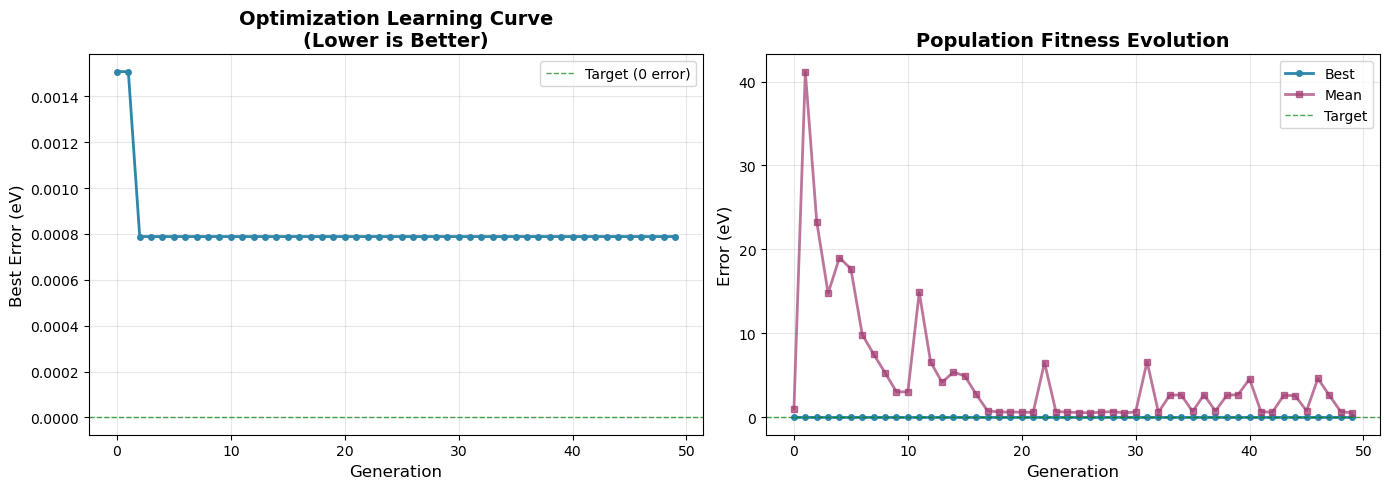


OPTIMIZATION SUMMARY
Target Energy:              1.2 eV
Best Error Achieved:        0.0002 eV
Best Composition:           CrMnO2
Best Coordination Number:   2
Predicted Energy:           1.2002 eV
Unique Compositions (final CN sweep):     48
Unique Compositions (final population):  48
Unique Best-so-far Compositions:         2
Final Generation Best:      MnO2
Final Generation CN:        3


In [29]:
# ==============================================================================
# USAGE EXAMPLE
# ==============================================================================
max_atoms = 15
# Initialize the GA optimizer
ga_optimizer = MaterialInverseDesignGA(
    model=xgb_model_top10,  # Your trained XGB model
    elemental_property_df=elementalProperty,  # Your elemental property DataFrame
    metal_elements=['O', 
                     'Cr', 'Mn', 'Fe', 'Co', 'Ni', 
                    'Ir', 'Pt', 'Mg', "Li", 'Ca', 'Sc', 'Ti'],
    target_value=1.2,
    population_size=500,
    generations=50,
    elite_size=2,
    mutation_rate=0.3,
    crossover_rate=0.7
 )

# After GA finishes
print("Starting Genetic Algorithm Optimization...")
print("=" * 60)
final_population, final_fitness = ga_optimizer.evolve(verbose=True)

print("\n" + "="*70)
print("DEBUG: History Values")
print("="*70)
print(f"First 10 best_fitness values: {ga_optimizer.history['best_fitness'][:10]}")
print(f"Last 10 best_fitness values: {ga_optimizer.history['best_fitness'][-10:]}")
print(f"Min fitness: {min(ga_optimizer.history['best_fitness'])}")
print(f"Max fitness: {max(ga_optimizer.history['best_fitness'])}")
print("="*70)

# Get best candidates
print("\n" + "=" * 60)
print("OPTIMIZATION COMPLETE")
print("=" * 60)

final_results = []
seen_compositions = set()  # Track unique normalized compositions

for comp_dict in final_population:
    normalized_comp = ga_optimizer.normalize_composition(comp_dict)
    comp_str = ga_optimizer.composition_to_formula(normalized_comp)

    if comp_str in seen_compositions:
        continue
    seen_compositions.add(comp_str)

    cn_results = ga_optimizer.evaluate_composition_all_CNs(normalized_comp)
    for result in cn_results:
        result['formula'] = comp_str
    final_results.extend(cn_results)

results_df = pd.DataFrame(final_results)

if results_df.empty:
    raise ValueError("No valid candidates were generated.")

results_df = results_df.drop_duplicates(subset=['formula', 'CN'])
results_df = results_df.sort_values('error').reset_index(drop=True)

print("\n" + "="*70)
print("TOP 20 CANDIDATES (NON-REPEATING COMPOSITIONS)")
print("="*70)
print(f"{'Rank':<6}{'Formula':<15}{'CN':<6}{'Predicted (eV)':<18}{'Error (eV)':<12}")
print("-"*70)

for idx, row in results_df.head(20).iterrows():
    print(f"{idx+1:<6}{row['formula']:<15}{row['CN']:<6}{row['predicted_energy']:<18.4f}{row['error']:<12.4f}")

print("="*70)

top_unique = get_top_n_unique_compositions(results_df, n=10)

print("\n" + "="*70)
print("TOP 10 UNIQUE COMPOSITIONS (BEST COORDINATION NUMBER)")
print("="*70)
print(f"{'Rank':<6}{'Formula':<15}{'Best CN':<10}{'Predicted (eV)':<18}{'Error (eV)':<12}")
print("-"*70)

for idx, row in top_unique.iterrows():
    print(f"{idx+1:<6}{row['formula']:<15}{row['CN']:<10}{row['predicted_energy']:<18.4f}{row['error']:<12.4f}")

print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Best fitness over generations
generations = list(range(len(ga_optimizer.history['best_fitness'])))
ax1.plot(generations, ga_optimizer.history['best_fitness'], 
         marker='o', linewidth=2, markersize=4, color='#2E86AB')
ax1.axhline(y=0, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Target (0 error)')
ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Best Error (eV)', fontsize=12)
ax1.set_title('Optimization Learning Curve\n(Lower is Better)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Best vs Mean fitness
ax2.plot(generations, ga_optimizer.history['best_fitness'], 
         marker='o', linewidth=2, markersize=4, color='#2E86AB', label='Best')
ax2.plot(generations, ga_optimizer.history['mean_fitness'], 
         marker='s', linewidth=2, markersize=4, color='#A23B72', alpha=0.7, label='Mean')
ax2.axhline(y=0, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Target')
ax2.set_xlabel('Generation', fontsize=12)
ax2.set_ylabel('Error (eV)', fontsize=12)
ax2.set_title('Population Fitness Evolution', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# ============================================================================
# Summary Statistics
# ============================================================================
history_unique = len(set(ga_optimizer.history['best_composition']))
final_unique = results_df['formula'].nunique()
final_unique_pop = len(seen_compositions)

print("\n" + "="*70)
print("OPTIMIZATION SUMMARY")
print("="*70)
print(f"Target Energy:              {ga_optimizer.target_value} eV")
print(f"Best Error Achieved:        {results_df['error'].min():.4f} eV")
print(f"Best Composition:           {results_df.iloc[0]['formula']}")
print(f"Best Coordination Number:   {results_df.iloc[0]['CN']}")
print(f"Predicted Energy:           {results_df.iloc[0]['predicted_energy']:.4f} eV")
print(f"Unique Compositions (final CN sweep):     {final_unique}")
print(f"Unique Compositions (final population):  {final_unique_pop}")
print(f"Unique Best-so-far Compositions:         {history_unique}")
print(f"Final Generation Best:      {ga_optimizer.history['best_composition'][-1]}")
print(f"Final Generation CN:        {ga_optimizer.history['best_CN'][-1]}")
print("="*70)

In [ ]:
print(['meanGroup','CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minGroup', 'maxAtomicRadius','meanAtomicRadius',     
            'minDensity', 'meanElectronegativity'])
feature_names = xgb_model_top10.get_booster().feature_names
comp_str = "RuO15"
features = compositionFeatureMapping_dynamic(comp_str, elementalProperty, feature_names)
print("Features for RuO15:", features)

# Compare to a normal oxide
comp_str_normal = "RuO2"
features_normal = compositionFeatureMapping_dynamic(comp_str_normal, elementalProperty, feature_names)
print("Features for RuO2:", features_normal)

['meanGroup', 'CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minGroup', 'maxAtomicRadius', 'meanAtomicRadius', 'minDensity', 'meanElectronegativity']
Features for RuO15: [[1.550000e+01 0.000000e+00 4.375000e-01 2.139000e+02 8.000000e+00
  2.070000e+02 1.554375e+02 1.429000e-03 3.362500e+00]]
Features for RuO2: [[1.33333333e+01 0.00000000e+00 2.33333333e+00 9.05240000e+02
  8.00000000e+00 2.07000000e+02 1.70333333e+02 1.42900000e-03
  3.02666667e+00]]
